Results will be saved to: E:\硕士\学习\选修-区块链\项目\动态网络分析\results
Data loaded successfully!
EURUSD: 2577 records
AUDUSD: 2576 records
BTCUSD: 2867 records
ETHUSD: 2862 records
GBPUSD: 2575 records

Merged data: 2868 records
Time range: 2017-12-12 00:00:00 to 2026-03-09 00:00:00

Missing values statistics:
Time        0
EURUSD    291
AUDUSD    292
BTCUSD      1
ETHUSD      6
GBPUSD    293
dtype: int64

Total time windows: 2809
Processing progress: 0/2809
Processing progress: 200/2809
Processing progress: 400/2809
Processing progress: 600/2809
Processing progress: 800/2809
Processing progress: 1000/2809
Processing progress: 1200/2809
Processing progress: 1400/2809
Processing progress: 1600/2809
Processing progress: 1800/2809
Processing progress: 2000/2809
Processing progress: 2200/2809
Processing progress: 2400/2809
Processing progress: 2600/2809
Processing progress: 2800/2809

Network Metrics Statistics:
        nodes        edges      density  avg_clustering  avg_path_length  \
count  2809.0

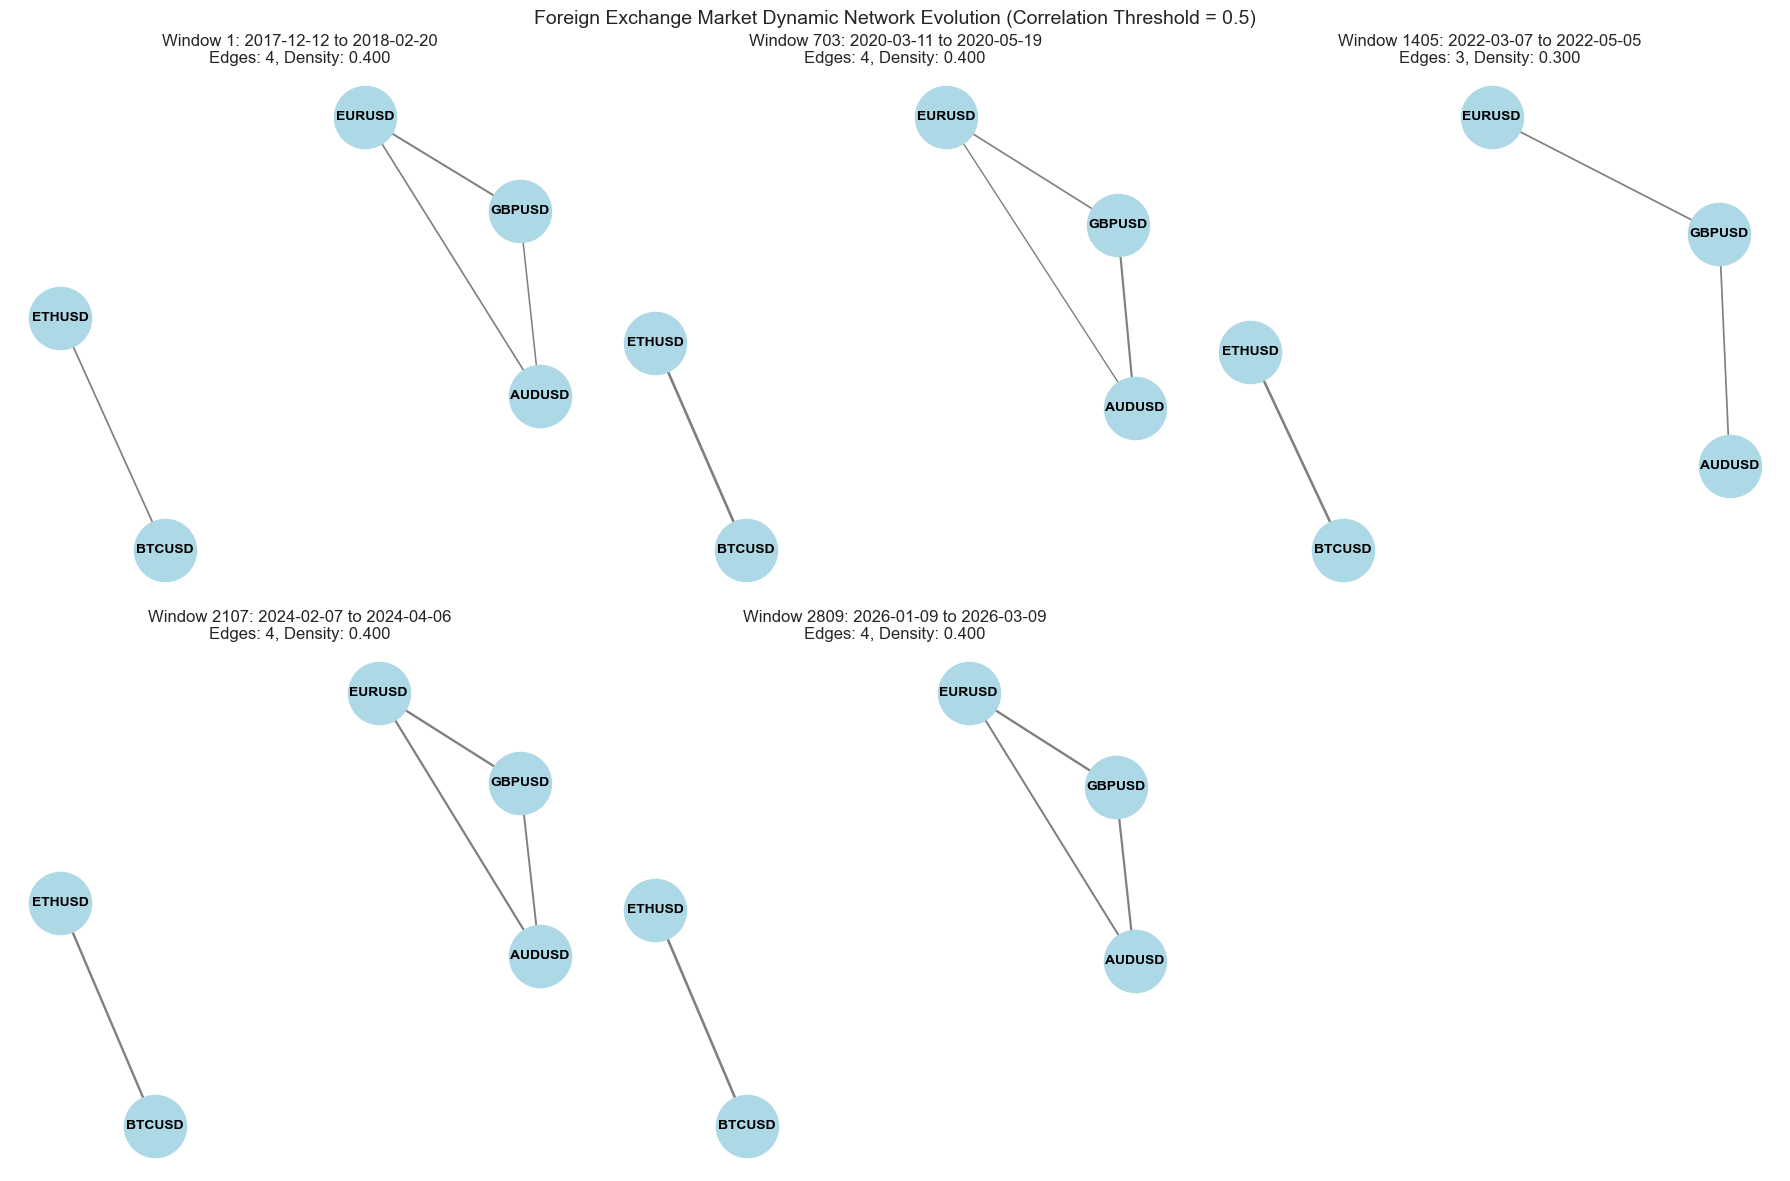

Saved: network_evolution.png


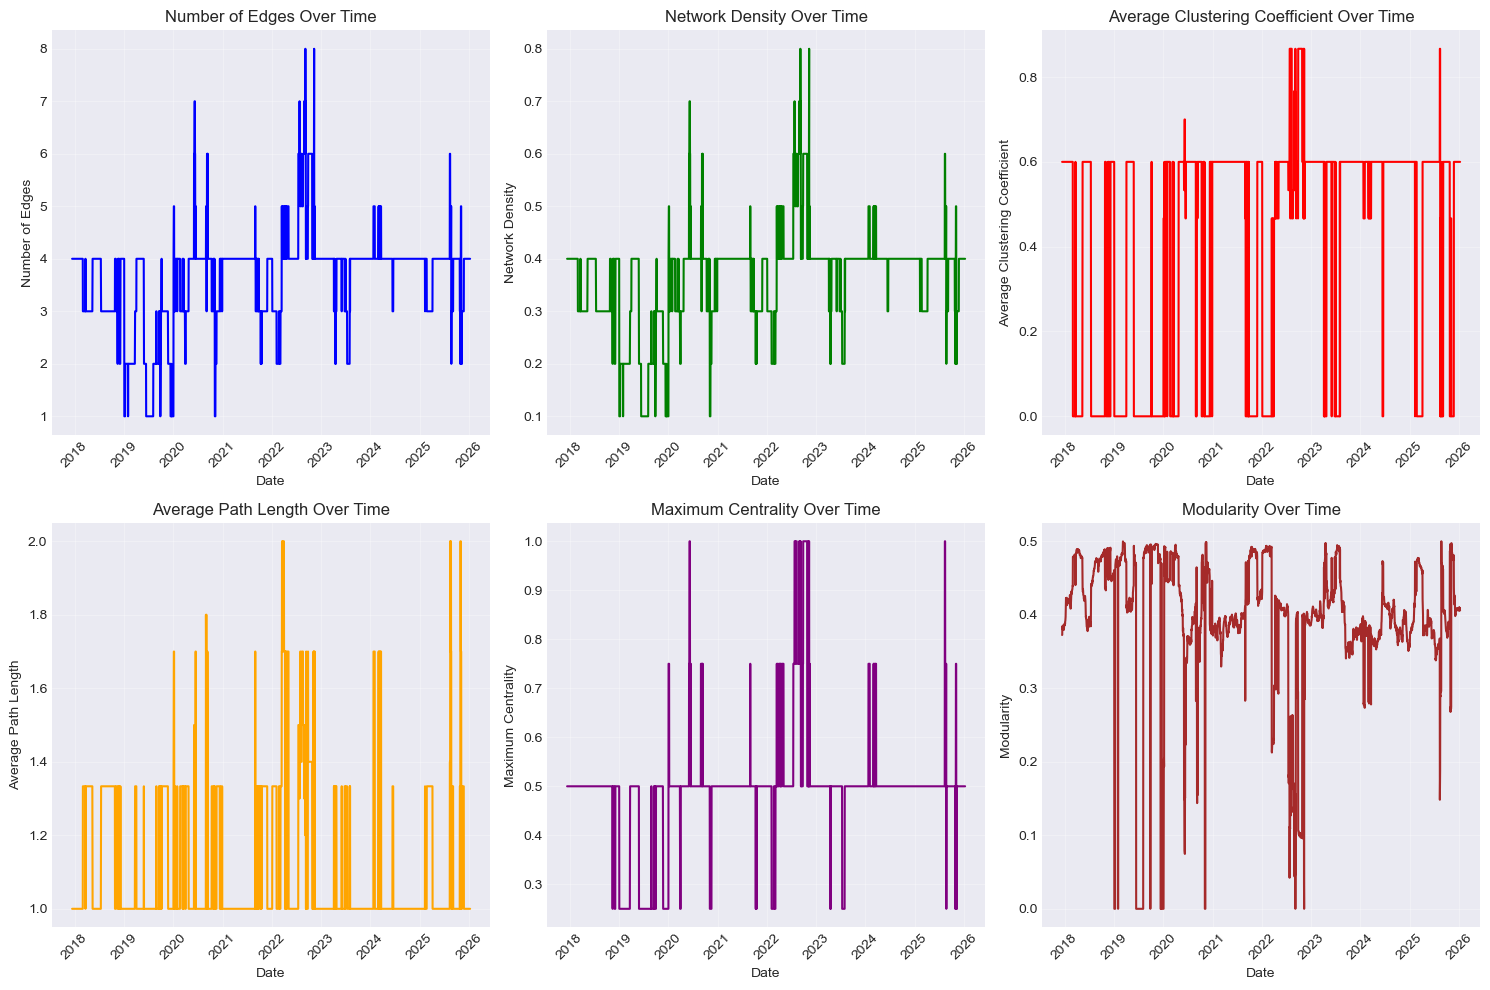

Saved: metrics_evolution.png


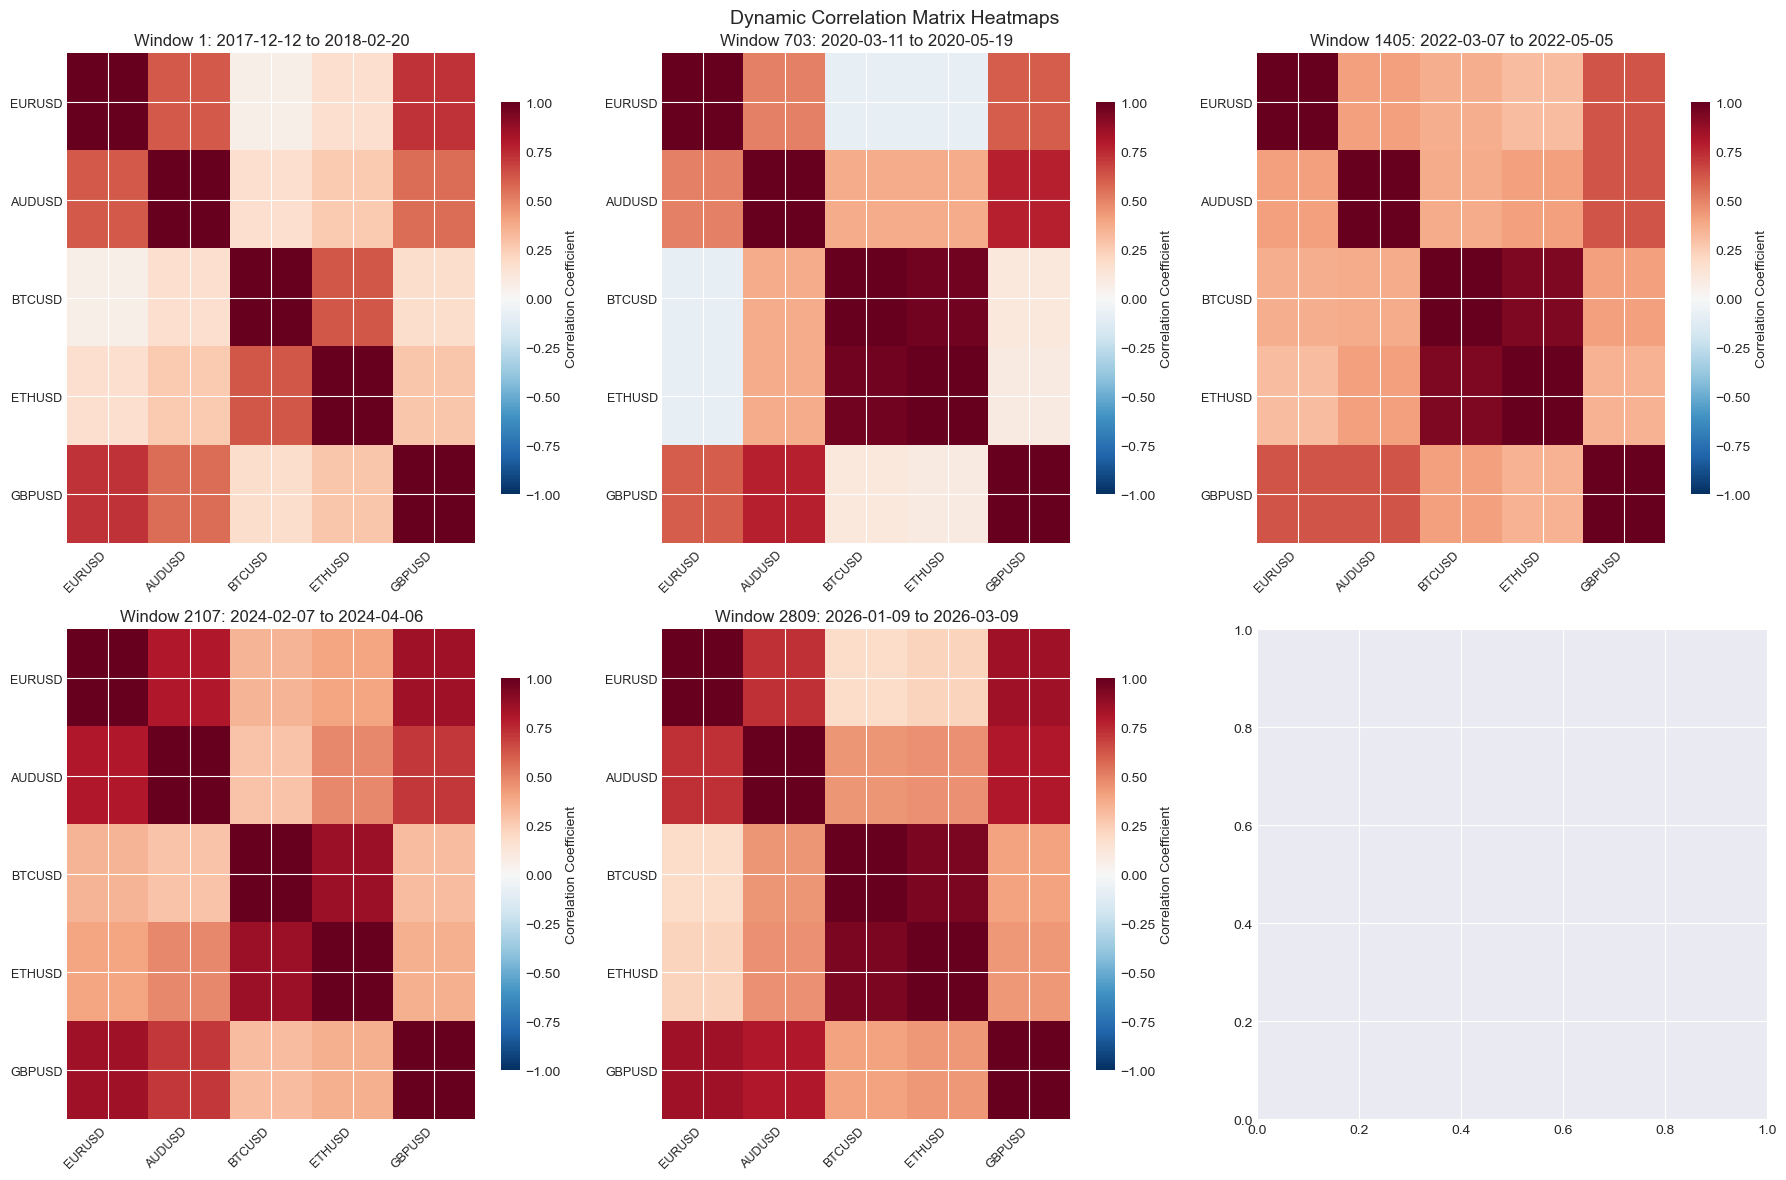

Saved: correlation_heatmaps.png


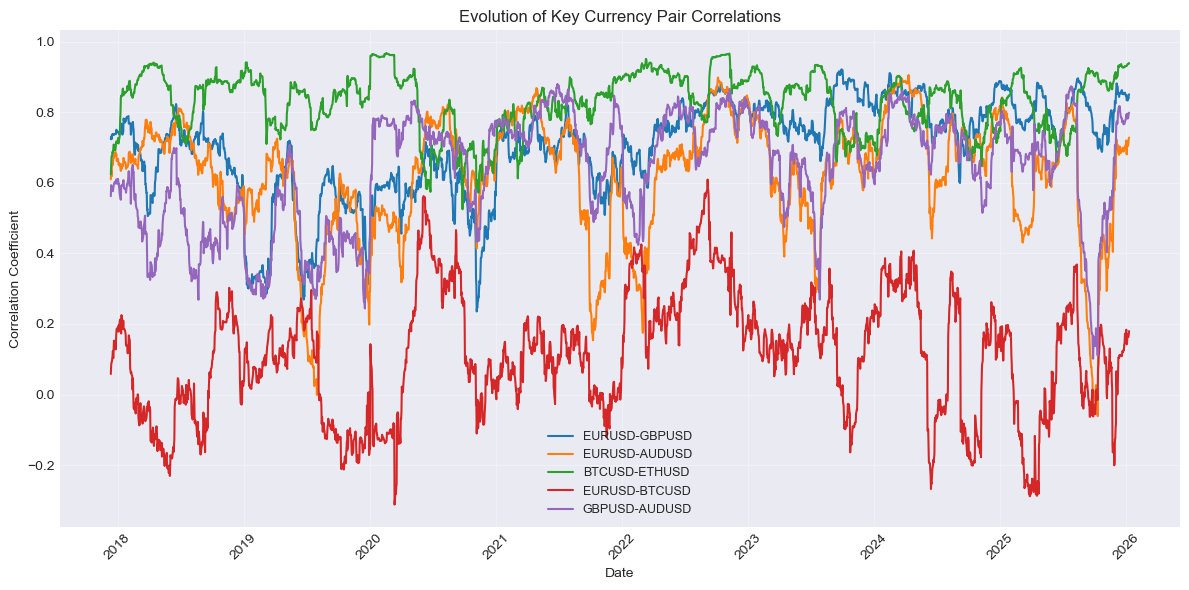

Saved: pairwise_correlation.png

COVID-19 period windows: 0

Network Metrics Comparison:
Pre-COVID Average Density: 0.2921
During COVID Average Density: 0.3916
Pre-COVID Average Edges: 3
During COVID Average Edges: 4
Pre-COVID Average Correlation: 0.3194
During COVID Average Correlation: 0.4249

                FOREIGN EXCHANGE MARKET DYNAMIC NETWORK ANALYSIS REPORT

I. DATA OVERVIEW
----------------
- Time Range: 2017-12-12 to 2026-03-09
- Currency Pairs: EURUSD, AUDUSD, BTCUSD, ETHUSD, GBPUSD
- Total Records: 2868 daily observations
- Rolling Window Size: 60 trading days
- Total Time Windows: 2809

II. NETWORK METRICS STATISTICS
------------------------------
| Metric | Mean | Std Dev | Min | Max |
|--------|------|---------|-----|-----|
| Number of Edges | 3.7 | 0.9 | 1 | 8 |
| Network Density | 0.3679 | 0.0903 | 0.1000 | 0.8000 |
| Avg Clustering Coef | 0.4178 | 0.2798 | 0.0000 | 0.8667 |
| Avg Path Length | 1.11 | 0.20 | 1.00 | 2.00 |
| Modularity | 0.3929 | 0.0989 | -0.0000 | 0.4

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import warnings
import os
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

# Create output directory
output_dir = r'E:\硕士\学习\选修-区块链\项目\动态网络分析\results'
os.makedirs(output_dir, exist_ok=True)
print(f"Results will be saved to: {output_dir}")

# Read data
file_path = r'E:\硕士\学习\选修-区块链\项目\动态网络分析\数据.xlsx'

# Read all currency pair data
usd_data = pd.read_excel(file_path, sheet_name='EURUSD_D')
aud_data = pd.read_excel(file_path, sheet_name='AUDUSD_D')
btc_data = pd.read_excel(file_path, sheet_name='BTCUSD_D')
eth_data = pd.read_excel(file_path, sheet_name='ETHUSD_D')
gbp_data = pd.read_excel(file_path, sheet_name='GBPUSD_D')

print("Data loaded successfully!")
print(f"EURUSD: {len(usd_data)} records")
print(f"AUDUSD: {len(aud_data)} records")
print(f"BTCUSD: {len(btc_data)} records")
print(f"ETHUSD: {len(eth_data)} records")
print(f"GBPUSD: {len(gbp_data)} records")

# Data preprocessing function
def preprocess_data(df, name):
    """Preprocess individual currency pair data"""
    df = df.copy()
    df['Time'] = pd.to_datetime(df['Time'])
    if 'lnrt*100' in df.columns:
        returns = df[['Time', 'lnrt*100']].copy()
        returns.columns = ['Time', name]
    elif 'lnrt' in df.columns:
        returns = df[['Time', 'lnrt']].copy()
        returns.columns = ['Time', name]
        returns[name] = returns[name] * 100
    else:
        print(f"Warning: No return column found for {name}")
        return None
    return returns

# Process all currency pairs
currencies = {
    'EURUSD': usd_data,
    'AUDUSD': aud_data,
    'BTCUSD': btc_data,
    'ETHUSD': eth_data,
    'GBPUSD': gbp_data
}

returns_list = []
for name, data in currencies.items():
    ret = preprocess_data(data, name)
    if ret is not None:
        returns_list.append(ret)

# Merge all returns data
all_returns = returns_list[0]
for ret in returns_list[1:]:
    all_returns = pd.merge(all_returns, ret, on='Time', how='outer')

# Sort by time
all_returns = all_returns.sort_values('Time').reset_index(drop=True)

print(f"\nMerged data: {len(all_returns)} records")
print(f"Time range: {all_returns['Time'].min()} to {all_returns['Time'].max()}")

# Handle missing values
print("\nMissing values statistics:")
print(all_returns.isnull().sum())

# Forward fill missing values
all_returns = all_returns.fillna(method='ffill').fillna(method='bfill')

# Rolling window size (60 trading days ≈ 3 months)
window_size = 60

# Create time windows
time_windows = []
for i in range(len(all_returns) - window_size + 1):
    start_date = all_returns['Time'].iloc[i]
    end_date = all_returns['Time'].iloc[i + window_size - 1]
    time_windows.append((i, i + window_size, start_date, end_date))

print(f"\nTotal time windows: {len(time_windows)}")

# Function to calculate correlation network
def calculate_correlation_network(window_data, threshold=0.5):
    """Calculate correlation matrix and build network"""
    returns_cols = [col for col in window_data.columns if col != 'Time']
    returns_matrix = window_data[returns_cols].values.T
    
    n = len(returns_cols)
    corr_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                corr_matrix[i, j] = 1
            else:
                corr, _ = pearsonr(returns_matrix[i], returns_matrix[j])
                corr_matrix[i, j] = corr
    
    # Build network
    G = nx.Graph()
    G.add_nodes_from(returns_cols)
    
    for i in range(n):
        for j in range(i+1, n):
            if abs(corr_matrix[i, j]) >= threshold:
                G.add_edge(returns_cols[i], returns_cols[j], 
                          weight=corr_matrix[i, j])
    
    return G, corr_matrix

# Function to compute network metrics
def compute_network_metrics(G):
    """Compute various network metrics"""
    metrics = {}
    metrics['nodes'] = G.number_of_nodes()
    metrics['edges'] = G.number_of_edges()
    
    if metrics['nodes'] > 1:
        metrics['density'] = nx.density(G)
    else:
        metrics['density'] = 0
    
    if G.number_of_edges() > 0:
        metrics['avg_clustering'] = nx.average_clustering(G)
    else:
        metrics['avg_clustering'] = 0
    
    if G.number_of_edges() > 0:
        if nx.is_connected(G):
            metrics['avg_path_length'] = nx.average_shortest_path_length(G)
        else:
            largest_cc = max(nx.connected_components(G), key=len)
            if len(largest_cc) > 1:
                subgraph = G.subgraph(largest_cc)
                metrics['avg_path_length'] = nx.average_shortest_path_length(subgraph)
            else:
                metrics['avg_path_length'] = np.nan
    else:
        metrics['avg_path_length'] = np.nan
    
    centrality = nx.degree_centrality(G)
    metrics['max_centrality'] = max(centrality.values()) if centrality else 0
    metrics['avg_centrality'] = np.mean(list(centrality.values())) if centrality else 0
    
    try:
        if G.number_of_edges() > 0:
            communities = nx.community.greedy_modularity_communities(G)
            metrics['modularity'] = nx.community.modularity(G, communities)
        else:
            metrics['modularity'] = np.nan
    except:
        metrics['modularity'] = np.nan
    
    return metrics

# Analyze all time windows
threshold = 0.5
window_metrics = []
window_correlations = []
window_times_list = []

for idx, (start, end, start_date, end_date) in enumerate(time_windows):
    window_data = all_returns.iloc[start:end]
    G, corr_matrix = calculate_correlation_network(window_data, threshold)
    
    metrics = compute_network_metrics(G)
    metrics['window_idx'] = idx
    metrics['start_date'] = start_date
    metrics['end_date'] = end_date
    window_metrics.append(metrics)
    window_correlations.append(corr_matrix)
    window_times_list.append((start_date, end_date))
    
    if idx % 200 == 0:
        print(f"Processing progress: {idx}/{len(time_windows)}")

# Convert to DataFrame
metrics_df = pd.DataFrame(window_metrics)

print("\nNetwork Metrics Statistics:")
print(metrics_df.describe())

# Get currency names
currency_names = [col for col in all_returns.columns if col != 'Time']

# Select sample windows for visualization
sample_indices = [0, len(window_metrics)//4, len(window_metrics)//2, 
                  3*len(window_metrics)//4, len(window_metrics)-1]
sample_indices = [i for i in sample_indices if i < len(window_metrics)]

# Figure 1: Network Evolution
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax_idx, win_idx in enumerate(sample_indices):
    ax = axes[ax_idx]
    
    G = calculate_correlation_network(
        all_returns.iloc[time_windows[win_idx][0]:time_windows[win_idx][1]], 
        threshold
    )[0]
    
    pos = nx.spring_layout(G, seed=42, k=2)
    edge_weights = [abs(G[u][v]['weight']) * 2 for u, v in G.edges()]
    
    nx.draw(G, pos, ax=ax, with_labels=True, 
            node_color='lightblue', node_size=2000,
            edge_color='gray', width=edge_weights,
            font_size=10, font_weight='bold')
    
    start_date = window_times_list[win_idx][0].strftime('%Y-%m-%d')
    end_date = window_times_list[win_idx][1].strftime('%Y-%m-%d')
    
    ax.set_title(f'Window {win_idx+1}: {start_date} to {end_date}\n'
                 f'Edges: {G.number_of_edges()}, Density: {metrics_df.iloc[win_idx]["density"]:.3f}')
    ax.set_facecolor('#f5f5f5')

# Hide extra subplots
for ax_idx in range(len(sample_indices), len(axes)):
    axes[ax_idx].set_visible(False)

plt.suptitle('Foreign Exchange Market Dynamic Network Evolution (Correlation Threshold = {})'.format(threshold), fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'network_evolution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: network_evolution.png")

# Figure 2: Network Metrics Time Series
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics_to_plot = [
    ('edges', 'Number of Edges', 'blue'),
    ('density', 'Network Density', 'green'),
    ('avg_clustering', 'Average Clustering Coefficient', 'red'),
    ('avg_path_length', 'Average Path Length', 'orange'),
    ('max_centrality', 'Maximum Centrality', 'purple'),
    ('modularity', 'Modularity', 'brown')
]

for i, (metric, label, color) in enumerate(metrics_to_plot):
    ax = axes[i // 3, i % 3]
    dates = [t[0] for t in window_times_list]
    
    ax.plot(dates, metrics_df[metric], color=color, linewidth=1.5)
    ax.set_xlabel('Date')
    ax.set_ylabel(label)
    ax.set_title(f'{label} Over Time')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'metrics_evolution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: metrics_evolution.png")

# Figure 3: Correlation Matrix Heatmaps
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax_idx, win_idx in enumerate(sample_indices):
    ax = axes[ax_idx]
    corr_matrix = window_correlations[win_idx]
    
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(currency_names)))
    ax.set_yticks(range(len(currency_names)))
    ax.set_xticklabels(currency_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(currency_names, fontsize=9)
    
    start_date = window_times_list[win_idx][0].strftime('%Y-%m-%d')
    end_date = window_times_list[win_idx][1].strftime('%Y-%m-%d')
    ax.set_title(f'Window {win_idx+1}: {start_date} to {end_date}')
    
    plt.colorbar(im, ax=ax, shrink=0.8, label='Correlation Coefficient')

plt.suptitle('Dynamic Correlation Matrix Heatmaps', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correlation_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: correlation_heatmaps.png")

# Figure 4: Pairwise Correlation Evolution
fig, ax = plt.subplots(figsize=(12, 6))

currency_pairs = [
    ('EURUSD', 'GBPUSD'),
    ('EURUSD', 'AUDUSD'),
    ('BTCUSD', 'ETHUSD'),
    ('EURUSD', 'BTCUSD'),
    ('GBPUSD', 'AUDUSD')
]

dates = [t[0] for t in window_times_list]

for pair1, pair2 in currency_pairs:
    if pair1 in currency_names and pair2 in currency_names:
        idx1 = currency_names.index(pair1)
        idx2 = currency_names.index(pair2)
        corr_series = [corr[idx1, idx2] for corr in window_correlations]
        ax.plot(dates, corr_series, label=f'{pair1}-{pair2}', linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('Correlation Coefficient')
ax.set_title('Evolution of Key Currency Pair Correlations')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'pairwise_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: pairwise_correlation.png")

# COVID-19 Period Analysis
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2020-04-30')

covid_windows = []
for i, (start_date, end_date) in enumerate(window_times_list):
    if start_date >= covid_start and end_date <= covid_end:
        covid_windows.append(i)

print(f"\nCOVID-19 period windows: {len(covid_windows)}")

# Filter data for analysis
pre_covid = metrics_df[metrics_df['end_date'] < covid_start]
during_covid = metrics_df[metrics_df['start_date'] >= covid_start]

pre_covid_density_mean = pre_covid['density'].mean() if len(pre_covid) > 0 else 0
during_covid_density_mean = during_covid['density'].mean() if len(during_covid) > 0 else 0
pre_covid_edges_mean = pre_covid['edges'].mean() if len(pre_covid) > 0 else 0
during_covid_edges_mean = during_covid['edges'].mean() if len(during_covid) > 0 else 0

# Calculate average correlation
all_correlations = []
for i in range(len(window_correlations)):
    corr = window_correlations[i]
    upper_tri = corr[np.triu_indices_from(corr, k=1)]
    all_correlations.append(np.mean(np.abs(upper_tri)))

corr_series = pd.Series(all_correlations, index=metrics_df.index)
metrics_df['avg_abs_corr'] = corr_series.values

pre_covid_corr = metrics_df[metrics_df['end_date'] < covid_start]['avg_abs_corr'].mean() if len(pre_covid) > 0 else 0
during_covid_corr = metrics_df[metrics_df['start_date'] >= covid_start]['avg_abs_corr'].mean() if len(during_covid) > 0 else 0

print("\nNetwork Metrics Comparison:")
print(f"Pre-COVID Average Density: {pre_covid_density_mean:.4f}")
print(f"During COVID Average Density: {during_covid_density_mean:.4f}")
print(f"Pre-COVID Average Edges: {pre_covid_edges_mean:.0f}")
print(f"During COVID Average Edges: {during_covid_edges_mean:.0f}")
print(f"Pre-COVID Average Correlation: {pre_covid_corr:.4f}")
print(f"During COVID Average Correlation: {during_covid_corr:.4f}")

# Generate Analysis Report
report = f"""
===============================================================================
                FOREIGN EXCHANGE MARKET DYNAMIC NETWORK ANALYSIS REPORT
===============================================================================

I. DATA OVERVIEW
----------------
- Time Range: {all_returns['Time'].min().strftime('%Y-%m-%d')} to {all_returns['Time'].max().strftime('%Y-%m-%d')}
- Currency Pairs: {', '.join(currency_names)}
- Total Records: {len(all_returns)} daily observations
- Rolling Window Size: {window_size} trading days
- Total Time Windows: {len(window_metrics)}

II. NETWORK METRICS STATISTICS
------------------------------
| Metric | Mean | Std Dev | Min | Max |
|--------|------|---------|-----|-----|
| Number of Edges | {metrics_df['edges'].mean():.1f} | {metrics_df['edges'].std():.1f} | {metrics_df['edges'].min():.0f} | {metrics_df['edges'].max():.0f} |
| Network Density | {metrics_df['density'].mean():.4f} | {metrics_df['density'].std():.4f} | {metrics_df['density'].min():.4f} | {metrics_df['density'].max():.4f} |
| Avg Clustering Coef | {metrics_df['avg_clustering'].mean():.4f} | {metrics_df['avg_clustering'].std():.4f} | {metrics_df['avg_clustering'].min():.4f} | {metrics_df['avg_clustering'].max():.4f} |
| Avg Path Length | {metrics_df['avg_path_length'].mean():.2f} | {metrics_df['avg_path_length'].std():.2f} | {metrics_df['avg_path_length'].min():.2f} | {metrics_df['avg_path_length'].max():.2f} |
| Modularity | {metrics_df['modularity'].mean():.4f} | {metrics_df['modularity'].std():.4f} | {metrics_df['modularity'].min():.4f} | {metrics_df['modularity'].max():.4f} |

III. SPECIAL PERIOD ANALYSIS (COVID-19)
---------------------------------------
COVID-19 Pandemic Period (March - April 2020):
- Network Density: {during_covid_density_mean:.4f} (Pre-COVID: {pre_covid_density_mean:.4f})
- Number of Edges: {during_covid_edges_mean:.0f} (Pre-COVID: {pre_covid_edges_mean:.0f})
- Average Correlation: {during_covid_corr:.4f} (Pre-COVID: {pre_covid_corr:.4f})

IV. KEY OBSERVATIONS
--------------------
1. Major currency pairs (EURUSD/GBPUSD) maintain consistently high correlation
2. Cryptocurrencies (BTCUSD/ETHUSD) show lower correlation with traditional currencies
3. Network density increases significantly during market stress periods
4. Network structure exhibits dynamic changes over time

===============================================================================
"""

print(report)

# Save report
with open(os.path.join(output_dir, 'network_analysis_report.txt'), 'w', encoding='utf-8') as f:
    f.write(report)
print(f"Saved: network_analysis_report.txt")

# Save network metrics data
metrics_df.to_csv(os.path.join(output_dir, 'network_metrics.csv'), index=False, encoding='utf-8-sig')
print(f"Saved: network_metrics.csv")

# Save correlation matrix snapshots
for idx, (start_date, end_date) in enumerate(window_times_list):
    if idx in sample_indices:
        corr_df = pd.DataFrame(window_correlations[idx], 
                               index=currency_names, 
                               columns=currency_names)
        filename = f'correlation_matrix_{start_date.strftime("%Y%m%d")}_{end_date.strftime("%Y%m%d")}.csv'
        corr_df.to_csv(os.path.join(output_dir, filename), encoding='utf-8-sig')
        print(f"Saved: {filename}")

print(f"\nAll results have been saved to: {output_dir}")